# 5. 레이블이 없는 데이터를 활용한 사전 훈련
이제 훈련 함수를 만들고 LLM을 사전 훈련할 차례이다. 생성된 텍스트의 품질을 평가하기 위해 기본적인 모델 평가 기법을 알아보자. 또한 사전 훈련된 가중치를 로드하는 방법을 배운다. 이 가중치가 LLM을 미세튜닝하기 위한 출발점이 된다.

## 5.1 텍스트 생성 모델 평가하기
4장에서 배운 텍스트 생성 과정을 간략히 정리한 후 텍스트 생성을 위해 LLM을 준비한다. 이어서 생성된 텍스트의 품질을 평가하는 기본적인 방법을 소개한다. 그런 다음 훈련 손실과 검증 손실을 계산한다.

### 5.1.1 GPT를 사용해 텍스트 생성하기
GPTModel 클래스와 GPT_CONFIG_124M 딕셔너리를 사용해 GPT 모델을 초기화한다.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/LLM
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
출력 크기: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],

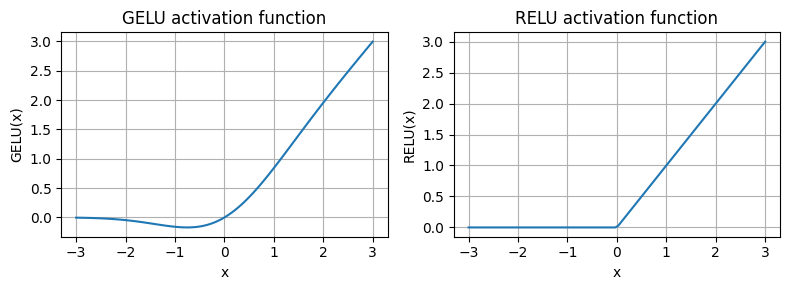

torch.Size([2, 3, 768])
layers.0.0.weight의 평균 그레이디언트는 0.00020173584925942123입니다.
layers.1.0.weight의 평균 그레이디언트는 0.00012011159560643137입니다.
layers.2.0.weight의 평균 그레이디언트는 0.0007152040489017963입니다.
layers.3.0.weight의 평균 그레이디언트는 0.0013988736318424344입니다.
layers.4.0.weight의 평균 그레이디언트는 0.005049645435065031입니다.
layers.0.0.weight의 평균 그레이디언트는 0.22169792652130127입니다.
layers.1.0.weight의 평균 그레이디언트는 0.20694108307361603입니다.
layers.2.0.weight의 평균 그레이디언트는 0.3289699852466583입니다.
layers.3.0.weight의 평균 그레이디언트는 0.2665732204914093입니다.
layers.4.0.weight의 평균 그레이디언트는 1.3258541822433472입니다.
입력 크기: torch.Size([2, 4, 768])
출력 크기: torch.Size([2, 4, 768])
입력 배치:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

출력 크기: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

%cd "/content/drive/MyDrive/Colab Notebooks/LLM"
%run "./ch04_implementing_a_GPT_model.ipynb"

In [ ]:
import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256, # 문맥 길이를 1,024에서 256으로 줄인다
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

GPTModel의 인스턴스 객체를 4장의 generate_text_simple 함수에 적용하고 2개의 유틸리티 함수 text_to_token_ids와 token_ids_to_text를 만든다. 이 함수들은 이 장에서 활용할 텍스트와 토큰 표현 사이의 변환을 수행한다.

In [ ]:
import tiktoken

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0) # 배치 차원 추가
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0) # 배치 차원 제거
  return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size = GPT_CONFIG_124M["context_length"]
)
print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


이 모델은 훈련되지 않았기 때문에 일관성 있는 텍스트를 만들지 못한다. '일관성이 있는' 텍스트나 '높은 품질의' 텍스트를 정의하려면 생성된 콘텐츠를 평가하기 위한 정량적인 방법이 있어야 한다. 이를 통해 훈련 과정에서 모델의 성능을 모니터링하고 향상시킬 수 있다. 다음 절에서 생성된 출력에 대한 손실을 계산한다. 이 손실은 훈련이 잘 진행되고 있는지 판단하는 성공 지표로 사용된다. 이후 장에서는 LLM을 미세 튜닝할 때 모델 품질을 평가하는 방법을 알아본다.

### 5.1.2 텍스트 생성 손실 계산하기
텍스트 생성 손실(text generate loss)을 계산하여 훈련 과정에서 생성된 텍스트 품질을 정량적으로 평가하는 기법을 알아보자.

2개의 입력 샘플("every efforts moves"와 "I really like")을 미리 토큰 ID로 매핑해놓자.


In [ ]:
inputs = torch.tensor([[16833, 3626, 6100], # every efforts moves
                       [40, 1107, 588]]) # I really like

# 입력에 대응하는 targets는 모델이 생성할 토큰 ID를 담고 있다
targets = torch.tensor([[3626, 6100, 345], # effort moves you
                        [1107, 588, 11311]]) # really like chocolate

targets는 한 위치 앞으로 이동한 입력이다.

입력을 모델에 주입하고 각각 3개의 토큰으로 구성된 입력 샘플 2개에 대한 로짓 벡터를 계산해보자. 그런 다음 softmax 함수를 적용해 로짓을 확률 점수(probas)로 변환한다.

In [ ]:
with torch.no_grad(): # 아직 훈련하지 않기 때문에 그레이디언트 추적을 끈다
  logits = model(inputs)
probas = torch.softmax(logits, dim=-1) # 어휘사전의 각 토큰에 대한 확률
print(probas.shape)

torch.Size([2, 3, 50257])


확률 점수 텐서(probas)의 차원은 다음과 같다.

확률 점수에 argmax 함수를 적용해 토큰 ID를 추출한다.

In [ ]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("토큰 ID:\n", token_ids)

토큰 ID:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


배치에 샘플이 2개이고, 각각 3개의 토큰이 있으므로 argmax 함수를 확률 점수에 적용하면 두 벌의 출력이 나온다. 각 출력은 예측한 3개의 토큰 ID를 담고 있다.

마지막으로 토큰 ID를 텍스트로 변환한다.

In [ ]:
print(f"첫 번째 샘플의 타깃: {token_ids_to_text(targets[0], tokenizer)}")
print(f"첫 번째 샘플의 출력: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

첫 번째 샘플의 타깃:  effort moves you
첫 번째 샘플의 출력:  Armed heNetflix


이 모델은 아직 훈련하지 않았기 때문에 타깃 텍스트와 다른 랜덤한 텍스트를 생성한다.

다음 코드로 2개의 입력 텍스트에 대해 타깃 토큰에 해당하는 초기 softmax 확률 점수를 출력한다.

In [ ]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("텍스트 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("텍스트 2:", target_probas_2)

텍스트 1: tensor([0.0001, 0.0000, 0.0000])
텍스트 2: tensor([0.0000, 0.0001, 0.0000])


LLM 훈련의 목표는 정답 토큰의 가능성을 최대화하는 것이다. 따라서 다른 토큰에 비해 정답 토큰의 확률을 높여야 한다.

손실을 계산하기 위한 단계이다.
1. 로짓
2. 확률
3. 타깃 토큰 확률
4. 로그 확률
5. 평균 로그 확률
6. 음의 평균 로그 확률

다음으로 두 샘플의 확률 점수 target_probas_1과 target_probas_2에 대한 손실을 계산한다.

target_probas_1과 target_probas_2를 얻기 위해 1~3단계까지 이미 수행했기 때문에 확률 점수에 로그를 적용하는 4단계를 진행한다.

In [ ]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


확률 점수에 로그를 적용하면 점수를 그대로 사용하는 것보다 수학적 최적화 과정에서 다루기 쉽다.

이 로그 확률을 평균하여 하나의 점수로 만든다.

In [ ]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


출력된 평균 로그 확률은 다음과 같다.

훈련 과정에서 모델의 가중치를 업데이트하여 평균 로그 확률이 가능한 0에 가깝게 만드는 것이 목표이다. 하지만 딥러닝에서는 일반적으로 평균 로그 확률을 0으로 만드는 것보다 음의 평균 로그 확률을 0으로 만든다. 음의 평균 로그 확률은 단순히 평균 로그 확률에 -1을 곱한 값이다. 이 단계가 6단계이다.

In [ ]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


이것을 크로스 엔트로피 손실이라 한다. 파이토치는 여섯 단계를 모두 처리하는 cross_entropy 함수를 기본으로 제공한다.

cross_entropy 함수를 적용하기 전에 로짓과 타깃 텐서의 크기를 간략히 확인해 보자.

In [ ]:
print("로짓 크기:", logits.shape)
print("타깃 크기:", targets.shape)

로짓 크기: torch.Size([2, 3, 50257])
타깃 크기: torch.Size([2, 3])


여기서 보듯이 logits 텐서는 3개의 차원을 가진다. 각각 배치 크기, 토큰 개수, 어휘사전 크기이다. targets 텐서는 배치 크기와 토큰 개수에 해당하는 2개의 차원을 가진다.

파이토치의 cross_entropy 손실 함수를 위해 처음 두 차원을 결합하여 두 텐서를 펼쳐야 한다.

In [ ]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("펼친 로짓:", logits_flat.shape)
print("펼친 타깃:", targets_flat.shape)

펼친 로짓: torch.Size([6, 50257])
펼친 타깃: torch.Size([6])


targets는 모델이 생성하길 기대하는 토큰 ID이다. logits는 확률 점수를 얻기 위해 softmax 함수로 들어가기 전의 정규화되지 않은 모델 출력을 담고 있다.

이전에는 softmax 함수를 적용하고, 타깃 ID에 해당하는 확률 점수를 선택하여 음의 평균 로그 확률을 계산했다. 파이토치의 cross_entropy 함수는 이런 단계를 모두 자동으로 수행한다.

In [ ]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


설명을 위해 2개의 텍스트 입력에 대한 손실을 계산했다. 이제 전체 훈련 세트와 검증 세트에 이 손실 계산을 적용한다.

### 5.1.3 훈련 세트와 검증 세트의 손실 계산하기
훈련 세트와 검증 세트의 손실을 계산하기 위해 2장에서 사용했던 "The Verdict"를 사용한다.

In [ ]:
import urllib.request

url = (
    "https://raw.githubusercontent.com/rickiepark/"
    "llm-from-scratch/main/ch02/01_main-chapter-code/"
    "the-verdict.txt"
)

file_path = "/content/the-verdict.txt"

urllib.request.urlretrieve(url, file_path)

with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("문자 수:", total_characters)
print("토큰 수:", total_tokens)

문자 수: 20479
토큰 수: 5145


그런 다음 데이터셋을 훈련 세트와 검증 세트로 나누고, 2장의 데이터 로더를 사용해 LLM 훈련을 위한 배치를 준비한다.

데이터 분할과 로딩을 구현하기 위해 train_ratio를 0.9로 지정하여 모델 훈련에 데이터의 90%를 사용하고 남은 10%를 평가를 위한 검증 세트로 사용한다.

In [ ]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

%cd "/content/drive/MyDrive/Colab Notebooks/LLM"

%run "./ch02_working_with_text_data.ipynb"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/LLM
총 문자 개수: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 
4690
['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']
1130
('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon'

In [ ]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [ ]:
print("훈련 데이터 로더:")
for x, y in train_loader:
  print(x.shape, y.shape)

print("\n검증 데이터 로더:")
for x, y in val_loader:
  print(x.shape, y.shape)

훈련 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

검증 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])


앞의 출력을 보면 9개의 훈련 세트 배치가 있다. 각 배치에는 2개의 샘플이 있고, 각 샘플은 256개의 토큰으로 구성된다. 데이터의 10%만 검증 세트로 할애했기 때문에 검증 세트 배치가 하나뿐이며, 샘플 2개로 구성된다.

그런 다음 훈련 데이터 로더와 검증 데이터 로더가 반환한 배치로 크로스 엔트로피 손실을 계산하는 유틸리티 함수를 구현한다.

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(
      logits.flatten(0, 1), target_batch.flatten()
  )
  return loss

하나의 배치에 대한 손실을 계산하는 calc_loss_batch 함수를 사용하여 다음에 등장하는 calc_loss_loader를 구현할 수 있다. 이 함수는 데이터 로더가 반환하는 모든 배치에 대한 손실을 계산한다.

In [ ]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0.
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader) # num_batches가 지정되지 않으면 모든 배치를 순회한다
  else:
    num_batches = min(num_batches, len(data_loader)) # num_batches가 데이터 로더에 있는 배치 개수보다 크면 배치 횟수를 데이터 로더에 있는 총 배치 개수로 맞춘다.
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(
          input_batch, target_batch, model, device
      )
      total_loss += loss.item() # 각 배치의 손실을 더한다
    else:
      break
  return total_loss / num_batches # 모든 배치의 손실을 평균한다


기본적으로 calc_loss_loader 함수는 주어진 데이터 로더에 있는 모든 배치를 순회하면서 total_loss에 손실을 누적한다. 그런 다음 배치 개수에 대해 손실의 평균을 계산한다.

훈련 데이터 로더와 검증 데이터 로더를 사용해 calc_loss_loader 함수를 직접 실행해보자.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad(): # 훈련하는 것이 아니므로 효율성을 위해 그레이디언트 추적을 끈다
  train_loss = calc_loss_loader(train_loader, model, device)
  val_loss = calc_loss_loader(val_loader, model, device)
print("훈련 손실:", train_loss)
print("검증 손실:", val_loss)

훈련 손실: 10.987583372328016
검증 손실: 10.98110580444336


모델이 아직 훈련되지 않았기 때문에 손실 값이 비교적 높다. 모델이 훈련 세트와 검증 세트에서 다음 토큰을 생성하는 방법을 학습하면 손실이 0에 가까워진다.

생성 텍스트의 품질을 측정하는 방법을 구현했으므로 LLM이 텍스트 생성을 더 잘 할 수 있도록 이 손실을 줄이기 위해 훈련하자.

이제 LLM 사전 훈련에 초점을 맞춘다. 모델을 훈련한 다음에 텍스트를 생성하는 다른 전략을 구현하고, 사전 훈련된 모델 가중치를 저장하고 로드하는 방법을 알아본다.

## 5.2 LLM 훈련하기
GPTModel LLM을 사전 훈련하기 위한 코드를 작성할 차례이다. 코드를 간결하고 가독성 있게 유지하기 위해 간단한 훈련 루프를 만든다.

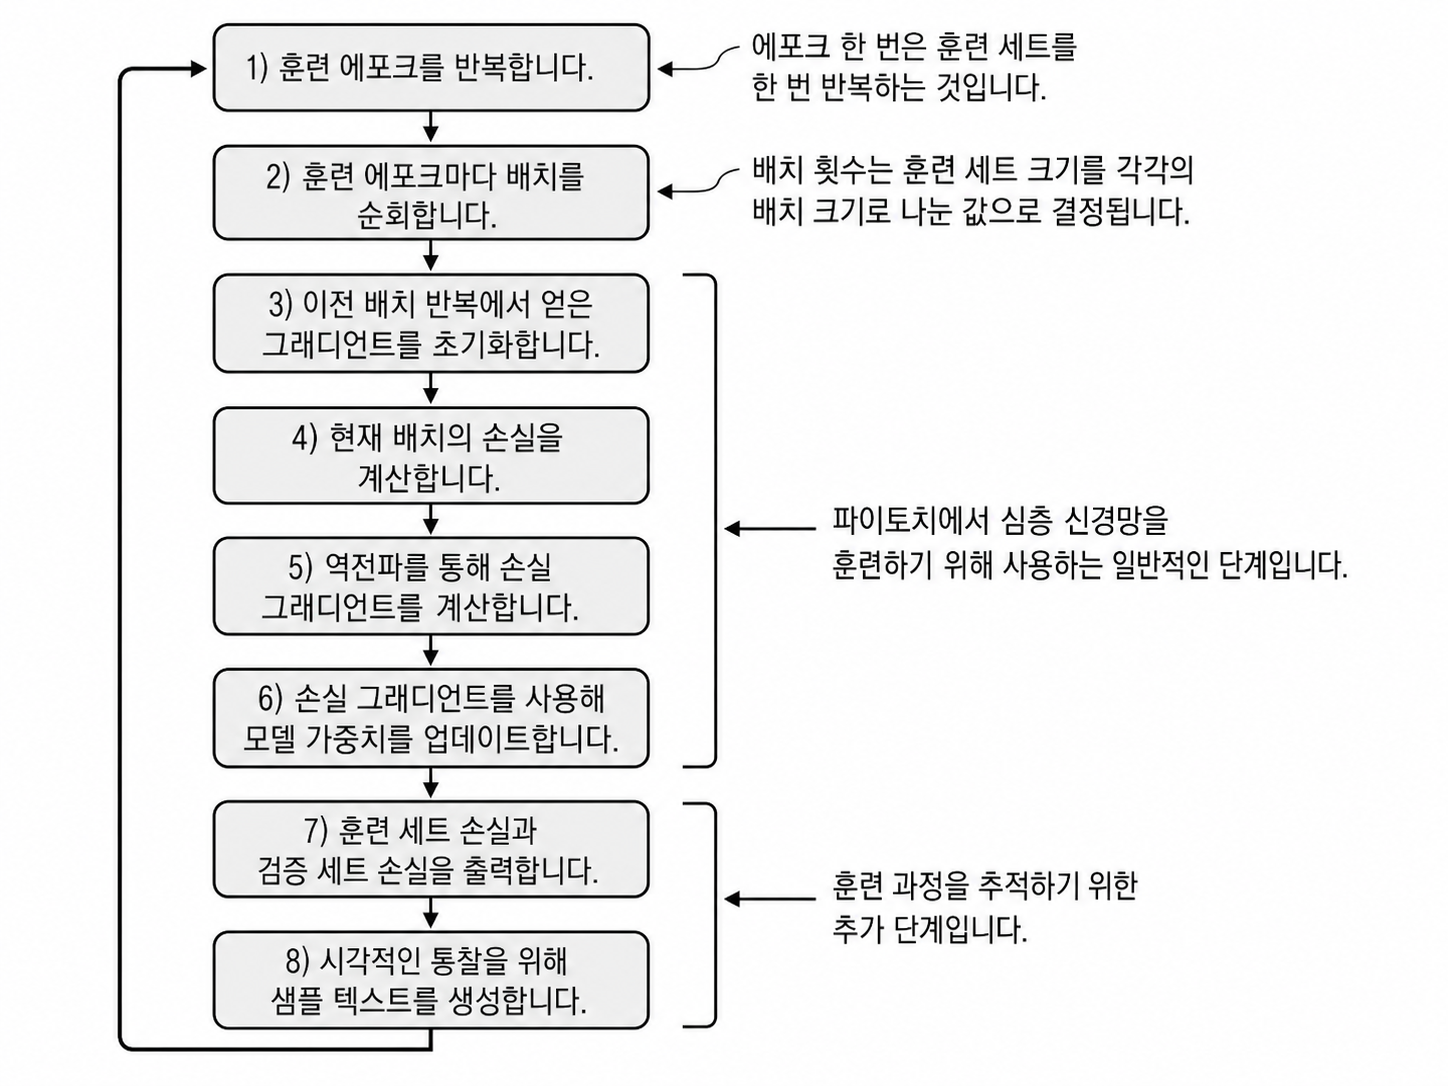


train_model_simple 함수로 이 훈련 단계를 구현한다.

In [ ]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen, global_step = 0, -1

  for epoch in range(num_epochs): # 메인 훈련 루프를 시작한다
    model.train()
    for input_batch, target_batch in train_loader:
      optimizer.zero_grad() # 이전 배치 반복에서 얻은 손실 그레이디언트를 초기화한다
      loss = calc_loss_batch(
          input_batch, target_batch, model, device
      )
      loss.backward() # 손실 그레이디언트를 계산한다
      optimizer.step() # 손실 그레이디언트를 사용하여 모델 가중치를 업데이트한다
      tokens_seen += input_batch.numel()
      global_step += 1

      if global_step % eval_freq == 0: # 추가적인 평가 단계
        train_loss, val_loss = evaluate_model(
            model, train_loader, val_loader, device, eval_iter
        )
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"에포크 {epoch+1} (Step {global_step:06d}): "
              f"훈련 손실 {train_loss:.3f}, "
              f"검증 손실 {val_loss:.3f}")

    generate_and_print_sample( # 각 에포크 후에 샘플 텍스트를 출력한다
        model, tokenizer, device, start_context
    )
  return train_losses, val_losses, track_tokens_seen


train_model_simple 함수는 아직 구현하지 않은 2개 함수 evaluate_model과 generate_and_print_sample을 사용한다.

evaluate_model 함수는 7단계에 해당한다. 모델이 업데이트된 후 모델이 향상되었는지 평가할 수 있도록 훈련 세트 손실과 검증 세트 손실을 출력한다. 더 구체적으로 evaluate_model 함수는 모델을 평가 모드로 설정하여 그레이디언트 추적과 드롭아웃을 비활성화하고 훈련 세트와 검증 세트에 대해 손실을 계산한다.

In [ ]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval() # 안정적이고 재현 가능한 결과를 위해 평가하는 동안 드롭아웃을 비활성화한다
  with torch.no_grad(): # 계산 오버헤드를 줄이기 위해 훈련 과정에서 필요하지 않은 그레이디언트 추적을 끈다
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=eval_iter
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=eval_iter
    )
    model.train()
    return train_loss, val_loss

evaluate_model과 비슷하게 generate_and_print_sample 함수는 모델이 훈련 과정에서 향상되었는지 추적하기 위해 편의상 만든 함수이다. 구체적으로 generate_and_print_sample 함수는 텍스트 조각(start_context)을 입력으로 받아 토큰 ID로 변환하고 LLM에 주입하여 앞에서 만든 geterate_text_simple로 샘플 텍스트를 생성한다.

In [ ]:
def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    token_ids = generate_text_simple(
        model=model, idx=encoded,
        max_new_tokens=50, context_size=context_size)
  decoded_text = token_ids_to_text(token_ids, tokenizer)
  print(decoded_text.replace("\n", " ")) # 간결한 출력 포맷
  model.train()

evaluate_model 함수가 모델 훈련 진행 과정에 대해 수치로 추정값을 제공하지만 generate_and_print_sample 함수는 모델이 생성한 구체적인 텍스트 샘플을 제공한다. 이를 통해 룬련하는 동안 모델의 성능을 평가할 수 있다.



> Adam은 심층 신경망을 훈련하는 데 인기 있는 옵티아미저이다. 하지만 우리 예에서는 **AdamW** 옵티마이저를 사용한다. AdamW는 가중치 감쇠 기법을 개선한 Adam의 변종이다. 모델의 복잡도를 낮추고 큰 페널티를 부과해 과대적합을 방지하는 것이 목표이다. 이런 조정을 통해 AdamW가 더 효과적으로 규제를 적용하고 더 나은 일반화를 달성할 수 있다.

AdamW 옵티마이저와 앞서 정의한 traim_model_simple 함수를 사용해 GPTModel 객체를 10 에포크 동안 훈련해보자.



In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

에포크 1 (Step 000000): 훈련 손실 9.818, 검증 손실 9.930
에포크 1 (Step 000005): 훈련 손실 8.066, 검증 손실 8.336
Every effort moves you,,,,,,,,,,,,.                                     
에포크 2 (Step 000010): 훈련 손실 6.623, 검증 손실 7.053
에포크 2 (Step 000015): 훈련 손실 6.047, 검증 손실 6.605
Every effort moves you, and,, and,,,,,,, and,.                                   
에포크 3 (Step 000020): 훈련 손실 5.532, 검증 손실 6.507
에포크 3 (Step 000025): 훈련 손실 5.399, 검증 손실 6.389
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
에포크 4 (Step 000030): 훈련 손실 4.895, 검증 손실 6.280
에포크 4 (Step 000035): 훈련 손실 4.648, 검증 손실 6.304
Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
에포크 5 (Step 000040): 훈련 손실 4.023, 검증 손실 6.165
Every effort moves you know                                                 
에포크 6 (Step 000045): 훈련 손실 3.625, 검증 손실 6.172
에포크 6 (S

모델의 언어 능력이 상당히 향상될 것을 확인할 수 있다.

훈련 세트 손실과 비슷하게 검증 세트 손실이 처음에는 높았다가 훈련하는 동안 감소한다. 하지만 훈련 세트 손실만큼 작아지지 않고 열 번의 에포크가 끝난 뒤에도 6.382로 남아 있다.

검증 세트 손실에 대해서 자세히 논의하기 전에 훈련 세트 손실과 검증 세트 손실을 나란히 보여주는 간단한 그래프를 그려 보자.

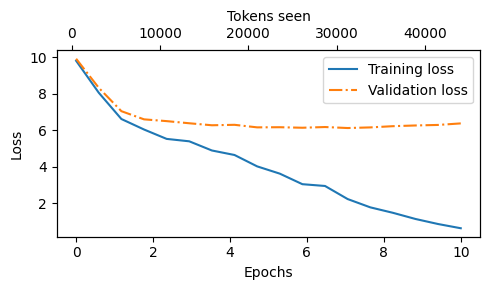

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
  fig, ax1 = plt.subplots(figsize=(5, 3))
  ax1.plot(epochs_seen, train_losses, label="Training loss")
  ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel("Loss")
  ax1.legend(loc="upper right")
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax2 = ax1.twiny()
  ax2.plot(tokens_seen, train_losses, alpha=0)
  ax2.set_xlabel("Tokens seen")
  fig.tight_layout()
  plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

여기서 볼 수 있듯이 훈련 손실과 검증 손실은 모두 첫 번째 에포크부터 향상되기 시작한다. 하지만 두 번째 에포크를 지나면서 두 손실이 벌어지기 시작한다. 이런 발산과 검증 손실이 훈련 손실보다 크다는 사실은 모델이 훈련 데이터에 과대적합되었다는 것을 나타낸다. "The Verdict" 텍스트 파일에서 모델이 생성한 텍스트와 같은 구절을 찾을 수 잇다. 이는 모델이 훈련 데이터를 그래도 기억하고 있는 것이다.

매우 작은 훈련 세트를 사용하고 모델을 여러 에포크에서 훈련하고 있기 때문에 이처럼 훈련 데이터를 그래도 암기해 버리는 현상을 예상할 수 있다. 일반적으로 LLM 모델은 훨씬 큰 데이터셋에서 딱 한 번의 에포크 동안 훈련한다.

다음으로 LLM을 위한 텍스트 생성 전략을 다룬다. 훈련 데이터를 암기하는 현상을 줄이고 LLM에서 생성된 텍스트의 독창성을 증가시키기 위한 방법이다. 그런 다음 가중치 저장과 로드를 설명하고 오픈AI의 GPT 모델에서 사전 훈련된 가중치를 로드하는 방법을 소개한다.

## 5.3 무작위성을 제어하기 위한 디코딩 전략
더 독창적인 텍스트를 생성하기 위한 텍스트 생성 전략(또는 디코딩 전략이라고 부른다)을 알아보자. 먼저 generate_and_print_sample 함수에서 사용된 generate_text_simple 함수를 간략하게 다시 살펴본다. 그런 다음 이 함수를 개선하기 위한 두 가지 방법, 온도 스케일링(temerature scaling)과 탑-k 샘플링을 소개한다.

비교적 작은 모델로 추론할 때는 GPU가 필요하지 않기 때문에 모델을 GPU에서 CPU로 다시 옮긴다. 또한 훈련한 다름에는 드롭아웃과 같은 랜덤한 구성 요소를 끄기 위해 모델을 평가 모드로 전환한다.

In [ ]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

GPTModel의 객체(model)를 generate_text_simple 함수에 전달하여 한 번에 하나의 토큰씩 텍스트를 생성한다.

In [77]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




이 토큰은 어휘사전에 있는 토큰 중에서 가장 높은 확률 점수를 가진 토큰이다.

### 5.3.1 온도 스케일링
이제 다음 토큰 생성 작업에 확률적 선택 과정을 추가하는 온도 스케일링 기법을 알아보자. 이전에 generate_text_simple 함수 안에서 torch.argmax를 사용해 항상 가장 높은 확률을 가진 토큰을 다음 토큰으로 선택했다. 이를 **그리디 디코딩**이라고 한다. 다양성이 더 높은 텍스트를 생성하기 위해 argmax를 확률 분포(여기서는 토큰 생성 단계마다 각 어휘사전 항목에 대해 LLM이 생성하는 확률 점수)로부터 샘플링하는 함수로 바꿀 수 있다.

확률적 샘플링을 구체적인 예를 들어 설명하기 위해 다음 토큰 생성 과정을 매우 작은 어휘사전으로 설명해보자.

In [78]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v:k for k, v in vocab.items()}

그런 다음 LLM이 시작 문맥으로 "every effort moves you"를 받고 다음과 같은 로짓을 생성했다고 가정한다.

In [79]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

generate_text_simple 함수 안에서 로짓을 softmax 함수를 통해 확률로 변환한다. 그런 다음 argmax 함수를 통해 생성 토큰에 해당하는 토큰 ID를 얻었다. 이를 역어휘사전을 통해 다시 텍스트로 매핑할 수 있다.

In [80]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


가장 큰 로짓 값과 이에 해당하는 가장 큰 softmax 확률 점수가 네 번째 위치(파이썬 인덱스 3)이기 때문에 생성될 단어는 forward이다.

확률적 샘플링 과정을 구현하기 위해 argmax를 파이토치의 multinomial 함수로 바꿀 수 있다.

In [81]:
torch.manual_seed(123)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


이전과 동일하게 forward가 출력된다. multinomial 함수는 확률 점수에 비례해서 다음 토큰을 샘플링한다. 다른 말로 하면 forward가 가장 가능성이 높은 토큰이기 때문에 항상은 아니지만 대부분의 경우 multinomial 함수에 의해 선택된다.

샘플링을 1,000번 수행하는 함수를 만들어보자.

In [82]:
def print_sampled_tokens(probas):
  torch.manual_seed(123)
  sample = [torch.multinomial(probas, num_samples=1).item()
            for i in range(1_000)]
  sampled_ids = torch.bincount(torch.tensor(sample))
  for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


여기서 볼 수 있듯이 forward가 가장 많이 선택된다.(1,000번 중 582번). 하지만 closer, inches, toward 같은 다른 토큰도 이따금 선택될 수 있다. generate_and_print_sample 함수에서 사용하는 argmax 함수를 multinomial 함수로 바꾸면 LLM이 "every effort moves you forward" 뿐만 아니라 이따금 "every effort moves to toward" 등 같은 텍스트를 생성한다는 의미이다.

**온도 스케일링(temperature scaling)** 이란 개념을 도입해 선택 과정을 더 제어할 수  있다. 온도 스케일링은 로짓을 0보다 큰 수로 나누는 방법이다.

In [83]:
def softmax_with_temperature(logits, temperature):
  scaled_logits = logits / temperature
  return torch.softmax(scaled_logits, dim=0)

1보다 큰 온도는 조금 더 균등한 토큰 확률 분포를 만든다. 1보다 작은 온도는 조금 더 결정론적인 분포(더 날카롭거나 뾰족한 분포)를 만든다. 이해하기 쉽도록 원본 확률 분포와 여러 개의 온도 값으로 스케일을 조정한 분포를 나란히 그려보자.

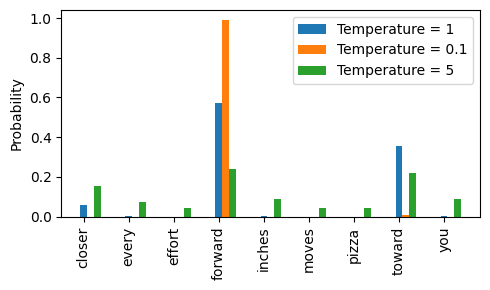

In [84]:
temperatures = [1, 0.1, 5] # 원본, 낮은 온도, 높은 온도

scaled_probas = [softmax_with_temperature(next_token_logits, T)
                 for T in temperatures]

x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))

for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],
                   bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

### 5.3.2 탑-k 샘플링
출력의 다양성을 증가시키기 위해 온도 스케일링을 사용하는 확률적 샘플링 방법을 구현했다. 따라서 모델이 가장 높은 확률의 토큰을 반복적으로 선택할 가능성을 낮추어 더 다양한 출력을 만든다. 이 방법은 생성 과정에서 가능성은 낮지만 전체적으로 더 흥미롭고 창의적인 경로를 탐색할 수 있게 한다. 하지만 이 방법의 한 가지 단점은 이따금 문법적으로 잘못되거나 "every effort moves you pizza" 처럼 완전히 말이 안 되는 출력을 만드는 것이다.

확률적 샘플링과 온도 스케일링을 결합한 탑-k 샘플링(top-k sampling)을 사용하면 텍스트 생성 결과를 향상시킬 수 있다. 탑-k 샘플링에서는 샘플링되는 토큰을 가장 가능성 있는 상위 k개의 토큰으로 제한한다. 다른 모든 토큰의 확률 점수는 마스킹하여 선택 과정에서 제외한다.

탑-k 방식은 선택되지 않은 모든 로짓을 음의 무한대 값으로 바꾼다. 따라서 softmax 값을 계산할 때 탑-k가 아닌 토큰의 확률 점수는 0이 되고 남은 토큰의 확률 합은 1이 된다.

탑-k 방식을 다음처럼 코드로 구현할 수 있다.

In [85]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("탑-k 로짓:", top_logits)
print("탑-k 위치:", top_pos)

탑-k 로짓: tensor([6.7500, 6.2800, 4.5100])
탑-k 위치: tensor([3, 7, 0])


내림차순으로 정렬된 상위 3개 토큰의 로짓값과 토큰 ID는 다음과 같다.

다음으로 파이토치의 where 함술르 사용해 탑-k 토큰 중에서 가장 마지막 토큰보다 작은 로짓값을 가진 모든 토큰의 로짓값을 음의 무한대(-inf)로 지정한다.

In [86]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1], # 탑-k 토큰 중 마지막 토큰보다 로짓이 작은 토큰을 찾는다
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


마지막으로 softmax 함수를 적용하여 이를 다음 토큰 확률로 바꾼다.

In [87]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


이제 온도 스케일링과 확률적 샘플링을 위한 multinomial 함수를 적용하여 0이 아닌 3개의 확률 점수에서 하나를 선택하여 다음 토큰을 생성할 수 있다. 텍스트 생성 함수를 수정하여 이를 수행해보자.

### 5.3.3 텍스트 생성 함수 수정하기
앞서 LLM으로 텍스트를 생성하기 위해 사용했던 generate_text_simple 함수에 온도 스케일링과 탑-k 샘플링을 적용하여 새로운 generate 함수를 만들어보자.

In [88]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
  for _ in range(max_new_tokens):
    idx_cond=idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]
    if top_k is not None:
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(
          logits < min_val,
          torch.tensor(float('-inf')).to(logits.device),
          logits
      )
    if temperature > 0.0:
      logits = logits / temperature
      probs = torch.softmax(logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)
    if idx_next == eos_id:
      break
    idx = torch.cat((idx, idx_next), dim=1)
  return idx

새로운 generate 함수를 테스트해보자.

In [89]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you?"
His up surprise. And whenever his glory, when by his head


결과에서 볼 수 있듯이 훈련 세트의 구절을 그대로 출력한 generate_simple 함수의 결과와 많이 다르다.

## 5.4 파이토치로 모델 저장하고 로드하기
지금까지 훈련 진행 상황을 평가하고 밑바닥부터 LLM을 사전 훈련하는 방법을 논의했다. LLM과 데이터셋 비교적 모두 작지만 이런 예제를 통해 LLM 사전 훈련에 계산 비용이 많이 든다는 것을 보여준다. 따라서 LLM을 나중에 재사용할 때 다시 훈련을 수행하지 않도록 모델을 저장하는 것이 중요하다.

이제 사전 훈련된 모델을 저장하고 로드하는 방법을 알아보자. 나중에 오픈 AI의 사전 훈련된 GPT 모델을 GPTModel 객체에 로드한다.

다행히 파이토치 모델을 저장하는 것은 비교적 간단하다. torch.save 함수를 사용해 모델의 층과 파라미터를 매핑한 딕셔너리인 state_dict를 저장하는 방법을 권장한다.

In [90]:
torch.save(model.state_dict(), "model.pth")

"model.pth"는 state_dict를 저장할 파일 이름이다. 관례적으로 파이토치에서는 .pth 확장자를 사용하지만 기술적으로는 어떤 확장자도 사용할 수 있다.

state_dict로 모델 가중치를 저장한 후에 이 가중치를 새로운 GPTModel 객체에 로드할 수 있다.

In [91]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

AdamW와 같은 적응형 옵티마이저는 모델 가중치마다 추가 파라미터를 저장한다. AdamW는 과거 데이터를 사용하여 각 모델 파라미터의 학습률을 동적으로 조정한다. 이 데이터가 없으면 옵티마이즈가 초기화되고 모델이 최적점이 아닌 곳으로 수렴하거나 아예 수렴하는 데 실패할 수도 있다. 이는 일관된 텍스트를 생성하는 능력을 얻지 못한다는 의미이다. torch.save를 사용하여 모델과 옵티마이저의 state_dict 내용을 모두 저장할 수 있다.

In [92]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth")

저장된 데이터를 먼저 torch.load로 로드하고, 그런 다음 load_state_dict 메서드로 모델과 옵티마이저의 상태를 복원할 수 있다.

In [93]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

## 5.5 오픈 AI에서 사전 훈련된 가중치 로드하기
앞서 하나의 단편 소설로 구성된 작은 데이터셋을 사용해 소규모 GPT-2 모델을 훈련했다. 이를 통해 많은 시간과 계산 자원을 사용하지 않고도 기본적인 원리를 배우는 데 초점을 맞출 수 있었다.

다행히 오픈 AI는 GPT-2 모델의 가중치를 공개적으로 제공하기 때문에 대규모 말뭉치에서 모델을 재훈련하기 위해 수만에서 수십만 달러를 쓸 필요가 없다. 이 가중치를 GPTModel 클래스에 로드하고 텍스트 생성에 사용해보자. 여기서 가중치(weight)란 파이토치의 Linear와 임베딩 층의 .weight 속성에 저장된 가중치 파라미터를 의미한다. 앞서 모델을 훈련할 때 model.parameters()를 사용해 가중치에 접근했다. 6장에서 이런 사전 훈련된 가중치를 재사용하여 텍스트 분류 작업을 위해 모델을 미세 튜닝하고, 7장에서 ChatGPT와 유사하게 지시를 따르도록 미세 튜닝한다.

In [94]:
import urllib.request

url = (
    "https://raw.githubusercontent.com/rickiepark/"
    "llm-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7880f55bbe00>)

이제 gpt_download.py 파일에서 download_and_load_gpt2 함수를 임포트한다. 이 함수를 사용해 GPT-2 구조 설정과 가중치 파라미터를 현재 파이썬 세션에 로드한다.

In [95]:
from gpt_download import download_and_load_gpt2
settings, params=download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 8.67kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 3.50MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 8.72kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:33<00:00, 14.9MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 235kiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 2.10MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 2.60MiB/s]


In [117]:
print("설정:", settings)
print("파라미터 딕셔너리 키:", params.keys())

설정: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
파라미터 딕셔너리 키: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


settings와 params 모두 파이썬 딕셔너리이다. settings 딕셔너리는 우리가 수동으로 만든 GPT_CONFIG_124M 딕셔너리와 비스하게 LLM 구조의 설정을 저장하고 있다. params 딕셔너리는 실제 가중치 텐서를 담고 있다. 가중치는 출력하기에 너무 많기 때문에 딕셔너리 키만 출력했다.

In [118]:
print(params["wte"])
print("토큰 임베딩 가중치 텐서의 차원:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
토큰 임베딩 가중치 텐서의 차원: (50257, 768)


GPT-2 모델 가중치를 파이썬으로 로드한 후 settings와 params 딕셔너리를 GPTModel 객체로 복사해야 한다. 먼저 GPT 모델 크기별 차이를 나열한 딕셔너리를 만든다.

In [119]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

가장 작은 모델인 "gpt-small (124M)"을 로드한다고 가정하자. 앞서 정의한 GPT_CONFIG_124M 설정을 model_configs 값으로 업데이트한다.

In [120]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

이전 예제에서는 256 토큰 길이를 사용했다. 하지만 오픈 AI의 원본 GPT-2 모델은 1,024 토큰 길이로 훈련되었다. 따라서 이를 반영하도록 NEW_CONFIG를 업데이트해야 한다.

In [121]:
NEW_CONFIG.update({"context_length": 1024})

또한 오픈 AI는 멀티 헤드 어텐션 모듈에서 쿼리, 키, 값 행렬을 계산하는 선형 층에 편향 벡터를 사용한다. 편향 벡터는 모델의 성능을 향상시키지 못해 불필요하기 때문에 LLM에서 더 이상 널리 사용되지 않는다. 하지만 사전 훈련된 가중치를 사용해야 하므로 편향 벡터를 사용할 수 있도록 설정을 맞춰야 한다.

In [122]:
NEW_CONFIG.update({"qkv_bias": True})

이제 NEW_CONFIG 딕셔너리를 사용해 GPTModel 클래스의 객체를 초기화할 수 있다.

In [123]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

기본적으로 GPTModel 객체는 랜덤한 가중치로 초기화된다. 오픈 AI의 모델 가중치를 사용하기 위한 마지막 단계는 이 랜덤한 가중치를 params 딕셔너리에 있는 가중치로 바꾸는 것이다. 이를 위해 간단한 assign 유틸리티 함수를 정의한다. 이 함수는 두 텐서나 배열(left나 right)이 크기가 같은지 검사하고 right를 훈련 가능한 파이토치 파라미터 텐서로 바꾸어 반환한다.

In [124]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(
            f"크기가 다릅니다. left: {left.shape}, "
            f"right: {right.shape}"
        )

    return torch.nn.Parameter(torch.tensor(right))

다음으로 params 딕셔너리의 가중치를 GPTModel의 인스턴스인 gpt로 로드하는 load_weights_into_gpt 함수를 정의한다.

In [125]:
import numpy as np


def load_weights_into_gpt(gpt, params):
    # 위치 임베딩과 토큰 임베딩의 가중치를 params의 값으로 설정합니다.
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    # 모델의 트랜스포머 블록을 순회합니다.
    for b in range(len(params["blocks"])):

        # np.split 함수를 사용해 어텐션 가중치와 편향 가중치를
        # 쿼리, 키, 값 세 부분으로 나눕니다.
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1
        )

        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T
        )
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T
        )
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T
        )

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1
        )

        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b
        )
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b
        )
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b
        )

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T
        )
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"]
        )

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T
        )
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"]
        )
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T
        )
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"]
        )

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"]
        )
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"]
        )
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"]
        )
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"]
        )

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])

    # 오픈AI의 원본 GPT-2 모델은 토큰 임베딩 가중치를 출력 층에
    # 재사용하여 전체 파라미터 개수를 절감하는 가중치 묶기를 사용합니다.
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

load_weights_into_gpt 함수에서 오픈 AI의 가중치와 GPTModel의 구현을 신중하게 매치한다. 구체적인 예를 들면 오픈 AI는 첫 번째 트랜스포머 블록의 출력 투영 층에 대한 가중치 텐서를 params["blocks"][0]["attn"]["c_proj"]["w"]로 저장한다. GPTModel의 인스턴스인 gpt에서 이에 해당하는 가중치 텐서는 gpt.trf_blocks[b].att.out_proj.weight이다.

load_weights_into_gpt 함수를 실행하고 오픈 AI의 모델 가중치를 GPTModel의 인스턴스인 gpt로 로드해보자.

In [126]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

generate 함수를 사용해 새로운 텍스트를 생성할 수 있다.

In [127]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle
